<a href="https://colab.research.google.com/github/IrisCheon/NLP-practice/blob/main/Korean_Exchange_Rate_News_Analysis_using_Google_News_Crawling_and_TF_IDF_(2025%E2%80%932026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Korean Exchange Rate News Analysis using Google News Crawling and TF-IDF (2025–2026)

This project collected Google News articles related to the Korean exchange rate from January 2025 to June 2026. The goal was to examine how news coverage evolved over time by analyzing monthly article volume, headline keywords using TF-IDF, and changes in the average USD/KRW exchange rate.

- exchange rate news from Jan 25 to Jun 26
- 검색어: "환율", "원달러 환율", "원화 약세", "달러
강세", "고환율", "환율 전망"
- 기간: 2025-01-01 - 2026-06-30
- 총 수집: 8094건
- 중복 제거 후: 5771건
- 저장 파일: exchange_news_2025_2026.csv

In [194]:
import pandas as pd

df = pd.read_csv(
    "/content/drive/MyDrive/1. data/개인 프로젝트/csv/exchange_news_2501_2606.csv"
)

In [195]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5771 entries, 0 to 5770
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   keyword       5771 non-null   object
 1   start_date    5771 non-null   object
 2   end_date      5771 non-null   object
 3   title         5771 non-null   object
 4   published     5771 non-null   object
 5   source        5771 non-null   object
 6   link          5771 non-null   object
 7   summary       5771 non-null   object
 8   published_dt  5771 non-null   object
 9   year          5771 non-null   int64 
 10  month         5771 non-null   object
dtypes: int64(1), object(10)
memory usage: 496.1+ KB


In [196]:
df.head()

,keyword,start_date,end_date,title,published,source,link,summary,published_dt,year,month
0,환율,2025-01-01,2025-02-01,2025년 달러는 더 사야 할까? 팔아야 할까? | KB의 생각 - KB Think,"Fri, 31 Jan 2025 08:00:00 GMT",KB Think,https://news.google.com/rss/articles/CBMiqgFBV...,"<a href=""https://news.google.com/rss/articles/...",2025-01-31 08:00:00,2025,2025-01
1,환율,2025-01-01,2025-02-01,주요 대기업의 환율 영향 조사 - KDI 경제교육,"Fri, 10 Jan 2025 08:00:00 GMT",KDI 경제교육,https://news.google.com/rss/articles/CBMia0FVX...,"<a href=""https://news.google.com/rss/articles/...",2025-01-10 08:00:00,2025,2025-01
2,환율,2025-01-01,2025-02-01,[수능에 나오는 경제·금융] 경제체력 보여주는 환율…수출과 연관성 약해져 - 생글생글,"Mon, 20 Jan 2025 08:00:00 GMT",생글생글,https://news.google.com/rss/articles/CBMiW0FVX...,"<a href=""https://news.google.com/rss/articles/...",2025-01-20 08:00:00,2025,2025-01
3,환율,2025-01-01,2025-02-01,윤석열과 트럼프가 밟은 환율 가속페달 - 시사IN,"Fri, 17 Jan 2025 08:00:00 GMT",시사IN,https://news.google.com/rss/articles/CBMiakFVX...,"<a href=""https://news.google.com/rss/articles/...",2025-01-17 08:00:00,2025,2025-01
4,환율,2025-01-01,2025-02-01,당국 개입도 먹히지 않아… 뉴노멀 1500원 환율 시대 오나 - 조선일보,"Mon, 06 Jan 2025 08:00:00 GMT",조선일보,https://news.google.com/rss/articles/CBMiakFVX...,"<a href=""https://news.google.com/rss/articles/...",2025-01-06 08:00:00,2025,2025-01


In [197]:
df.columns

Index(['keyword', 'start_date', 'end_date', 'title', 'published', 'source',
       'link', 'summary', 'published_dt', 'year', 'month'],
      dtype='object')

In [198]:
df.shape

(5771, 11)

#EDA

In [199]:
len(df)

5771

In [200]:
df["source"].value_counts()

,count
source,
v.daum.net,483
연합뉴스,394
KB Think,294
연합인포맥스,282
한국경제,219
...,...
한돈뉴스,1
한국금융신문,1
포천신문,1


In [201]:
month_counts = df["month"].value_counts().sort_index()
month_counts

,count
month,
2025-01,238
2025-02,209
2025-03,215
2025-04,244
2025-05,208
2025-06,175
2025-07,179
2025-08,169
2025-09,189


In [202]:
import matplotlib.pyplot as plt

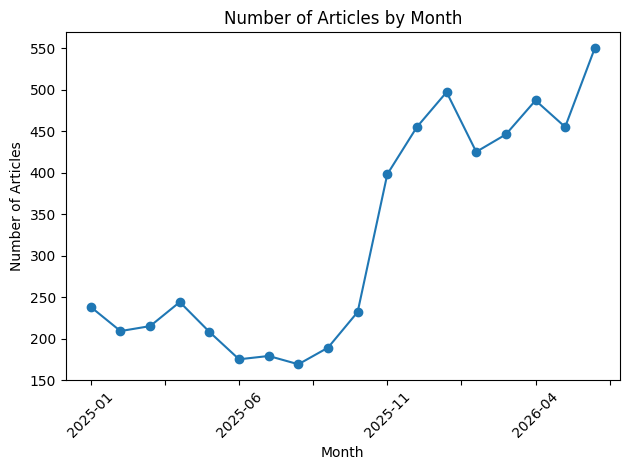

In [203]:
month_counts.plot(kind="line", marker="o")

plt.title("Number of Articles by Month")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [204]:
# 2025-11 환율 관련기사 급증

#TF-IDF

In [205]:
df_tfidf = df[
    ["title", "month", "keyword", "source", "published", "link"]
].copy()

In [206]:
import re

def clean_title(text):
    text = str(text)

    text = re.sub(r"<[^>]+>", " ", text)

    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)

    text = re.sub(r"\s+", " ", text).strip()

    return text

In [207]:
df_tfidf["title_clean"] = (
    df_tfidf["title"].apply(clean_title)
)

In [208]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    min_df = 3,
    max_df = 0.8,
    ngram_range = (1,2),
    max_features = 10000
)

tfidf_matrix = vectorizer.fit_transform(
    df_tfidf["title_clean"]
)

In [209]:
feature_names = vectorizer.get_feature_names_out()

tfidf_values = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns = feature_names,
    index = df_tfidf.index
    # df_tfidf 데이터프레임의 인덱스와 맞추기 위함
)

## 월별 주요 단어 분석

In [210]:
monthly_tfidf = (
    tfidf_values
    .assign(month = df_tfidf["month"])  #tfidf 점수표에 month열 임시로 붙이기
    .groupby("month")
    .mean()     #같은 월의 기사들의 tf-idf 점수 평균
    .sort_index()
)

In [211]:
def get_top_terms_by_month(monthly_tfidf, top_n = 10):

    rows = []

    for month, scores in monthly_tfidf.iterrows():

        top_scores = scores.nlargest(top_n)

        for rank, (term, score) in enumerate(top_scores.items(), start=1):

            rows.append({
                "month" : month,
                "rank" : rank,
                "term" : term,
                "tfidf_score" : score
            })

    return pd.DataFrame(rows)

In [212]:
monthly_top_terms = get_top_terms_by_month(
    monthly_tfidf,
    top_n=10
)

In [213]:
monthly_table = (
    monthly_top_terms
    .pivot(
        index="rank",
        columns="month",
        values="term"
    )
)

monthly_table

month,2025-01,2025-02,2025-03,2025-04,2025-05,2025-06,2025-07,2025-08,2025-09,2025-10,2025-11,2025-12,2026-01,2026-02,2026-03,2026-04,2026-05,2026-06
rank,,,,,,,,,,,,,,,,,,
1,환율,환율,환율,환율,환율,환율,환율,달러,환율,환율,환율,환율,환율,달러,환율,환율,환율,환율
2,고환율,달러,달러,달러,달러,달러,달러,환율,달러,달러,달러,달러,달러,환율,달러,달러,달러,달러
3,달러,트럼프,가격,달러 환율,kb think,이재명,달러 환율,달러 환율,1400원,달러 환율,고환율,고환율,고환율,달러 환율,달러 환율,이란,kb think,daum
4,트럼프,물가,인상,관세,think,한국경제,daum,브런치,환율 1400원,daum,달러 환율,내년,원화,고환율,고환율,kb think,think,daum net
5,한국경제,서울경제,경향신문,연합뉴스,kb,이란,daum net,daum,daum,daum net,원화,달러 환율,달러 환율,전망,중동,think,kb,net
6,헤럴드경제,한국경제,달러 환율,최고,원화,마켓인,net,daum net,daum net,net,전망,고환율에,약세,강세,1500원,kb,원화,달러 환율
7,2025,1월,한국경제,강세,연합뉴스,코스피,상승,net,net,한국경제,한국경제,원화,연합뉴스,워시,전쟁,고환율,고환율,고환율
8,2025년,가격,트럼프,트럼프,달러 환율,원화,2분기,ebc,달러 환율,돌파,1500원,전망,원화 약세,연합인포맥스,고유가,달러 환율,고금리,원화
9,달러 환율,관세,연합뉴스,1분기,한국경제,정부,마감,ebc financial,한국,급등,약세,정부,한국,엔화,원화,전망,달러 환율,전망


In [214]:
monthly_summary = (
    monthly_top_terms
    .sort_values(["month", "rank"])
    .groupby("month")
    .agg(
        top_terms=("term", lambda x: ", ".join(x))
    )
    .reset_index()
)

monthly_summary

,month,top_terms
0,2025-01,"환율, 고환율, 달러, 트럼프, 한국경제, 헤럴드경제, 2025, 2025년, 달러..."
1,2025-02,"환율, 달러, 트럼프, 물가, 서울경제, 한국경제, 1월, 가격, 관세, 연합뉴스"
2,2025-03,"환율, 달러, 가격, 인상, 경향신문, 달러 환율, 한국경제, 트럼프, 연합뉴스, 최상목"
3,2025-04,"환율, 달러, 달러 환율, 관세, 연합뉴스, 최고, 강세, 트럼프, 1분기, 만에"
4,2025-05,"환율, 달러, kb think, think, kb, 원화, 연합뉴스, 달러 환율, ..."
5,2025-06,"환율, 달러, 이재명, 한국경제, 이란, 마켓인, 코스피, 원화, 정부, 달러 환율"
6,2025-07,"환율, 달러, 달러 환율, daum, daum net, net, 상승, 2분기, 마..."
7,2025-08,"달러, 환율, 달러 환율, 브런치, daum, daum net, net, ebc, ..."
8,2025-09,"환율, 달러, 1400원, 환율 1400원, daum, daum net, net, ..."
9,2025-10,"환율, 달러, 달러 환율, daum, daum net, net, 한국경제, 돌파, ..."


※ 기사 제목 위주라 크게 내용의 차이는 없음.
- '이란', '중동', '고유가' 등은 2025-06 등장 후 사라졌다가 2026-03, 2026-04 재 등장

In [215]:
monthly_top_terms[
    monthly_top_terms["month"]=="2025-11"
]

,month,rank,term,tfidf_score
100,2025-11,1,환율,0.046986
101,2025-11,2,달러,0.035159
102,2025-11,3,고환율,0.031989
103,2025-11,4,달러 환율,0.024820
104,2025-11,5,원화,0.023350
105,2025-11,6,전망,0.018061
106,2025-11,7,한국경제,0.017688
107,2025-11,8,1500원,0.016974
108,2025-11,9,약세,0.015966
109,2025-11,10,daum,0.015736


## 주 언론사별 주요 단어 분석

In [216]:
source_counts = df_tfidf["source"].value_counts()

for n in [5, 10, 15, 20]:
    coverage = source_counts.head(n).sum() / len(df_tfidf) * 100
    print(f"Top {n}: {coverage:.2f}%")

Top 5: 28.97%
Top 10: 41.54%
Top 15: 50.55%
Top 20: 56.96%


※ 상위 15개 언론사를 선택했을 때 전체 기사의 50%를 포함

In [217]:
# 기사 수 많은 언론사 추려내기(top 15)

top_sources = (
    df_tfidf["source"]
    .value_counts()
    .head(15)
)

top_sources

,count
source,
v.daum.net,483
연합뉴스,394
KB Think,294
연합인포맥스,282
한국경제,219
마켓인,169
경향신문,149
이투데이,141
중앙일보,137


In [218]:
top_sources = (
    df_tfidf["source"]
    .value_counts()
    .head(15)
    .index
)

In [219]:
df_top = df_tfidf[
    df_tfidf["source"].isin(top_sources)
].copy()

In [220]:
#TF-IDF

tfidf_matrix = vectorizer.fit_transform(
    df_top["title_clean"]
)

feature_names = vectorizer.get_feature_names_out()

In [221]:
tfidf_values = pd.DataFrame(
    tfidf_matrix.toarray(),
    columns=feature_names,
    index=df_top.index
)

In [222]:
source_tfidf = (
    tfidf_values
    .assign(source=df_top["source"])
    .groupby("source")
    .mean()
)

In [223]:
def get_top_terms_by_source(source_tfidf, top_n = 10):

    rows = []

    for source, scores in source_tfidf.iterrows():

        top_scores = scores.nlargest(top_n)

        for rank, (term, score) in enumerate(top_scores.items(), start=1):

            rows.append({
                "source" : source,
                "rank" : rank,
                "term" : term,
                "tfidf_score" : score
            })

    return pd.DataFrame(rows)

In [224]:
source_top_terms = get_top_terms_by_source(
    source_tfidf,
    top_n=10
)

In [225]:
source_table = (
    source_top_terms
    .pivot(
        index="rank",
        columns="source",
        values="term"
    )
)

source_table

source,Chosunbiz,KB Think,KBS 뉴스,YTN,v.daum.net,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,,,,
1,chosunbiz,kb,kbs,ytn,daum,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
2,조선비즈,kb think,kbs 뉴스,환율,daum net,환율,환율,fx 서울경제,환율,달러,환율전망,환율,환율,환율,환율
3,조선비즈 chosunbiz,think,뉴스,달러 환율,net,고환율,달러,김혜란의,달러,환율,환율전망 이투데이,원화,원화값,달러,달러
4,달러 환율,전망,환율,달러,환율,달러 환율,강세,김혜란의 fx,달러 환율,강세,등락,달러,고환율,고환율,달러 환율
5,환율,환율 전망,코스피,코스피,달러,달러,지속,fx,그래픽,고환율,등락 환율전망,원화 환율,이코노믹스,달러 환율,원화
6,달러,환율,달러,마감,달러 환율,원화,약세,환율,추이,원화,시도,고환율,1500원,원화,고환율
7,오른,전망 kb,급락 kbs,경제,고환율,코스피,고환율,달러,추이 연합뉴스,전망,달러,1500원,고환율에,고공행진,만에
8,개장 조선비즈,달러,달러 환율,굿모닝경제,원화,상승,전망,달러 환율,환율 추이,거래,강세,환율은,원화,약세,1500원
9,마감,fx 전망,머니 kbs,굿모닝경제 ytn,약세,고유가,엔화,고환율,그래픽 달러,한은,상승,만에,물가,다시,외환시장


## 월 x 언론사 분석

In [226]:
month_source_tfidf = (
    tfidf_values.assign(
        month = df_tfidf["month"],
        source = df_tfidf["source"]
    )
    .groupby(["month", "source"])
    .mean()
    .sort_index()
)

In [227]:
month_source_tfidf.index

MultiIndex([('2025-01',  'Chosunbiz'),
            ('2025-01',   'KB Think'),
            ('2025-01',     'KBS 뉴스'),
            ('2025-01', 'v.daum.net'),
            ('2025-01',       '경향신문'),
            ('2025-01',        '마켓인'),
            ('2025-01',       '서울경제'),
            ('2025-01',       '연합뉴스'),
            ('2025-01',     '연합인포맥스'),
            ('2025-01',       '이투데이'),
            ...
            ('2026-06',       '경향신문'),
            ('2026-06',        '마켓인'),
            ('2026-06',       '서울경제'),
            ('2026-06',       '연합뉴스'),
            ('2026-06',     '연합인포맥스'),
            ('2026-06',       '이투데이'),
            ('2026-06',       '조선일보'),
            ('2026-06',       '중앙일보'),
            ('2026-06',        '한겨레'),
            ('2026-06',       '한국경제')],
           names=['month', 'source'], length=257)

In [228]:
# 기사 수 적은 조합 제거

month_source_counts = (
    df_tfidf
    .groupby(["month", "source"])
    .size()
    .rename("article_count")
)

In [229]:
month_source_counts.head()

month    source    
2025-01  :: 위즈경제 ::    1
         Chosunbiz     7
         DailyNK       1
         IT조선          2
         KB Think      8
Name: article_count, dtype: int64

In [230]:
month_source_tfidf = (
    month_source_tfidf.join(month_source_counts)
)

In [231]:
# 조합 내 기사가 3개 이상인 경우만 필터링

month_source_tfidf_filtered = (
    month_source_tfidf[
        month_source_tfidf["article_count"] >= 3
    ].copy()
)

In [232]:
from numpy import column_stack
# 모든 월x언론사의 상위 단어 추출

def get_top_terms_by_month_source(grouped_tfidf, top_n=10):
    rows = []

    for (month, source), scores in grouped_tfidf.iterrows():
        top_scores = scores.nlargest(top_n)

        for rank, (term, score) in enumerate(top_scores.items(), start=1):
            rows.append({
                "month": month,
                "source": source,
                "rank": rank,
                "term": term,
                "tfidf_score": score
            })

    return pd.DataFrame(rows)

In [233]:
month_source_top_terms = get_top_terms_by_month_source(
    month_source_tfidf_filtered,
    top_n=10
)

In [234]:
month_source_top_terms

,month,source,rank,term,tfidf_score
0,2025-01,Chosunbiz,1,article_count,7.000000
1,2025-01,Chosunbiz,2,chosunbiz,0.269580
2,2025-01,Chosunbiz,3,조선비즈,0.269580
3,2025-01,Chosunbiz,4,조선비즈 chosunbiz,0.269580
4,2025-01,Chosunbiz,5,etf에,0.092485
...,...,...,...,...,...
2235,2026-06,한국경제,6,약세의,0.063401
2236,2026-06,한국경제,7,원화 약세의,0.063401
2237,2026-06,한국경제,8,버틴,0.062681
2238,2026-06,한국경제,9,분석 한국경제,0.061332


In [235]:
target_month = "2025-11"

table_2025_11 = (
    month_source_top_terms[
        month_source_top_terms["month"] == target_month
    ]
    .pivot(
        index="rank",
        columns="source",
        values="term"
    )
)

table_2025_11

source,Chosunbiz,KB Think,KBS 뉴스,YTN,v.daum.net,경향신문,마켓인,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,kbs,ytn,daum,경향신문,마켓인,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,kbs 뉴스,달러 환율,daum net,국민연금,환율,그래픽 달러,고환율 충격,환율전망,주가,금융위기,주목할,간다
4,조선비즈 chosunbiz,think,뉴스,환율,net,울상,1480원,추이 연합뉴스,충격,실수요,원화 가치,비트코인,구조적,달러예금
5,원인,전망 kb,환율,달러,고환율,환율,주식,환율 추이,달러,환율전망 달러,환율,환율,약세,약세
6,원화,전망,달러,475원,1500원,원화,달러,추이,원가,예상 이투데이,원화,1470원대,환율,돌파
7,원화 약세,11월,7개월 만에,코스피,환율,1480원,달러 강세,그래픽,적정환율,하락 예상,1500원,환율 급등,고환율,환율
8,소폭 올라,진입,머니 kbs,3원 마감,시대,넘게,넘는,환율,고환율,선호,가치,이후 최저,환헤지,돌파 한국경제
9,약세,환율 전망,잇슈,서학개미 투자에,달러,달러 환율,강세,달러 환율,엔화,하락,희비,기업,원화,고환율


In [236]:
for month in sorted(
    month_source_top_terms["month"].unique()
):
    print(f"\n===== {month} =====")

    table = (
        month_source_top_terms[
            month_source_top_terms["month"] == month
        ]
        .pivot(
            index="rank",
            columns="source",
            values="term"
        )
    )

    display(table)


===== 2025-01 =====


source,Chosunbiz,KB Think,v.daum.net,경향신문,마켓인,서울경제,연합뉴스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,daum,경향신문,마켓인,서울경제,연합뉴스,이투데이,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,daum net,한은,1450원대로,경기,그래픽,고환율에,경제포커스,이코노믹스,국내,올해
4,조선비즈 chosunbiz,think,net,늘었다,울상,트럼프,위안화,대기업,국민연금까지,최대,고환율에,어디로
5,etf에,일본,위기의 환율,환율,수요,마감,계엄,1300원대,5년,소상공인,원화 실질가치,트럼프
6,1400원대 전망,미국,위기의,12월,추가,출렁,수혜,상승세,5년 만에,투기,실질가치,다시
7,부터,동향 kb,환율 daum,부터,매각,발언에,하나,수입물가,개입도,경제,이탈,환율
8,달러보다,동향,동결,환율 30원,이유 마켓인,1년새,환율,불안,않아,한숨,장기,환차익
9,위기에,달러 상승,환율,외환보유액,해외,늘었다,대기업,내수,외환,금융당국,원화,여전히



===== 2025-02 =====


source,Chosunbiz,KB Think,v.daum.net,경향신문,서울경제,연합뉴스,연합인포맥스,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,daum,경향신문,서울경제,연합뉴스,연합인포맥스,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,daum net,1월,fx 서울경제,2위,안정될,엔화,헤지,우세,프라이스
4,조선비즈 chosunbiz,think,net,물가,김혜란의,높아,1조 달러,환율까지,자산,커져,프라이스 한국경제
5,업계,트럼프,1월,커피,김혜란의 fx,작년,않는,팔자,해외,두달째,금리인상
6,리츠,영향은,1월 외환보유액,오른다,fx,면세점,발언,고환율에도 달러,1월 외환보유액,비싼,물가
7,why,사상 최고치,소비자물가,최저치,단독,동조,전망 연합인포맥스,떨어진,7조,속도,무너져
8,어떻게,분위기,외환보유액,급등한,트럼프,eu,성장률,환전,되레,예금,강세
9,수입품,금값,환율,환율 하반기,글로벌,국민의힘,있다,고환율에도,달러보험,외화,타이밍



===== 2025-03 =====


...

source,Chosunbiz,KB Think,KBS 뉴스,YTN,v.daum.net,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,kbs,ytn,daum,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,kbs 뉴스,종전협상,daum net,산업별,환율,민간,이란,달러,환율전망 이투데이,나왔다,환율,3월,고환율
4,조선비즈 chosunbiz,think,뉴스,코스피,net,원화 약세,이유는 마켓인,pick코노미,환율,원화,환율전망,어떻게,물가,기업들,고환율에
5,5원,환율 전망,코스피,마감,고환율,고유가,1460원대,pick코노미 서울경제,환율 이란,신현송,등락 환율전망,목표가,환율에,구윤철,박스권
6,마감 조선비즈,전망,공급,하락 환율,고유가,고환율에,달러,ria,이란 협상,환율,등락,오른,1380원,구매력,워치
7,달러 환율,환율,800선,코스피 하락,달러,약세,이유는,안정에,협상,한은,낙관론,환율,뚫렸다,고르기,워치 한국경제
8,내린 1472,4월,3월,환율,달러 환율,구윤철 원화,역대,과도한 원화,마감 연합뉴스,강세,협상,1460원대로,아시아 통화,배경,구간
9,달러,달러,전략은,473,환율전망 daum,트럼프가,고환율의,과도한,달러,고환율,시도 환율전망,최고 환율,묶인,소폭 하락,전쟁



===== 2026-05 =====


source,Chosunbiz,KB Think,KBS 뉴스,YTN,v.daum.net,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,고물가 고환율,ytn,daum,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,kbs,굿모닝경제,daum net,단호히,경계,fx 서울경제,마감 연합뉴스,환율,환율전망 이투데이,고물가 고환율은,돌파 중앙일보,외국인,환율
4,조선비즈 chosunbiz,think,kbs 뉴스,굿모닝경제 ytn,net,환율,위험,김혜란의,이란 종전,뉴프레임,환율전망,고환율은,국채,하락 코스피,달러
5,달러 환율,전망,뉴스,넘어선,고금리,구두개입 필요시,고금리,김혜란의 fx,이란,환율 뉴프레임,등락 환율전망,김용범 고금리,1500원대 환율,수입업체,1500원
6,달러,환율 전망,고금리 고물가,성공의,고환율,필요시,갇힌 환율,fx,종전,원화,등락,고금리 고물가,원인,중동 전쟁,1500원선
7,마감 조선비즈,환율,성공의,성공의 비용,비용,김용범,전망 마켓인,보다,마감,500원대,1490원,김용범,돌파,비명,달러 환율
8,1원 오른,원화,성공의 비용,비용,성공의,24시간,한국은행,환율,축소,압력,1500원대,비용,급등,환율 1500원대,환율 채권
9,9원,5월,비용,온다,성공의 비용,조치,제시,안해,단호,반도체,종전,고금리,시간,팔고,경상흑자에도



===== 2026-06 =====


source,Chosunbiz,KB Think,KBS 뉴스,YTN,v.daum.net,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
rank,,,,,,,,,,,,,,,
1,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count,article_count
2,chosunbiz,kb,kbs,ytn,daum,경향신문,마켓인,서울경제,연합뉴스,연합인포맥스,이투데이,조선일보,중앙일보,한겨레,한국경제
3,조선비즈,kb think,kbs 뉴스,달러,daum net,마감,기대에 달러,늘었다,환율,고환율,환율전망 이투데이,전쟁,고환율 반도체,환율 1500원,환율
4,조선비즈 chosunbiz,think,뉴스,달러 환율,net,환율,내려간다,기업들,달러,외환,환율전망,원화 환율,반도체,1500원대,1550원
5,오른,환율 전망,500선,마감,환율,1500원대,1540원대,생산적,달러 환율,달러,등락할,한국경제,갇힌 환율,1500원,외국인
6,개장,전망,하락 kbs,종전,원화,사실상,만의,블룸버그,외국인,환율,등락할 환율전망,겹쳐,팔기,추가 상승,약세의
7,달러 환율,환율,코스피,경제,달러,종료,환율 이틀째,완만한,최고,기초가치,등락,고환율 반도체,팔아야,환율,원화 약세의
8,개장 조선비즈,달러,환율,우려,환율전망 daum,20원 마감,고유가 고환율에,금융,오른,강세,1540원,간다,물가,환율 고공행진,버틴
9,8원,뉴욕장서,환율도 하락,코스피 500,고환율,마감 경향신문,환율 하반기엔,고환율에,하락 연합뉴스,상황,종전,위험,한은,대통령 환율,분석 한국경제


###top5 언론사별 주요 단어

In [237]:
top_sources = (
    df_tfidf["source"]
    .value_counts()
    .head()
    .index
)

In [238]:
month_source_top_terms_top5 = (
    month_source_top_terms[
        month_source_top_terms["source"].isin(top_sources)
    ]
)

In [239]:
for month in sorted(
    month_source_top_terms_top5["month"].unique()
):
    print(f"\n===== {month} =====")

    table = (
        month_source_top_terms_top5[
            month_source_top_terms_top5["month"] == month
        ]
        .pivot(
            index = "rank",
            columns = "source",
            values = "term"
        )
    )

    display(table)


===== 2025-01 =====


source,KB Think,v.daum.net,연합뉴스,한국경제
rank,,,,
1,article_count,article_count,article_count,article_count
2,kb,daum,연합뉴스,한국경제
3,kb think,daum net,그래픽,올해
4,think,net,위안화,어디로
5,일본,위기의 환율,계엄,트럼프
6,미국,위기의,수혜,다시
7,동향 kb,환율 daum,하나,환율
8,동향,동결,환율,환차익
9,달러 상승,환율,대기업,여전히



===== 2025-02 =====


source,KB Think,v.daum.net,연합뉴스,연합인포맥스,한국경제
rank,,,,,
1,article_count,article_count,article_count,article_count,article_count
2,kb,daum,연합뉴스,연합인포맥스,한국경제
3,kb think,daum net,2위,안정될,프라이스
4,think,net,높아,1조 달러,프라이스 한국경제
5,트럼프,1월,작년,않는,금리인상
6,영향은,1월 외환보유액,면세점,발언,물가
7,사상 최고치,소비자물가,동조,전망 연합인포맥스,무너져
8,분위기,외환보유액,eu,성장률,강세
9,금값,환율,국민의힘,있다,타이밍



===== 2025-03 =====


...

source,KB Think,v.daum.net,연합뉴스,연합인포맥스,한국경제
rank,,,,,
1,article_count,article_count,article_count,article_count,article_count
2,kb,daum,연합뉴스,연합인포맥스,한국경제
3,kb think,daum net,이란,달러,고환율
4,think,net,환율,원화,고환율에
5,환율 전망,고환율,환율 이란,신현송,박스권
6,전망,고유가,이란 협상,환율,워치
7,환율,달러,협상,한은,워치 한국경제
8,4월,달러 환율,마감 연합뉴스,강세,구간
9,달러,환율전망 daum,달러,고환율,전쟁



===== 2026-05 =====


source,KB Think,v.daum.net,연합뉴스,연합인포맥스,한국경제
rank,,,,,
1,article_count,article_count,article_count,article_count,article_count
2,kb,daum,연합뉴스,연합인포맥스,한국경제
3,kb think,daum net,마감 연합뉴스,환율,환율
4,think,net,이란 종전,뉴프레임,달러
5,전망,고금리,이란,환율 뉴프레임,1500원
6,환율 전망,고환율,종전,원화,1500원선
7,환율,비용,마감,500원대,달러 환율
8,원화,성공의,축소,압력,환율 채권
9,5월,성공의 비용,단호,반도체,경상흑자에도



===== 2026-06 =====


source,KB Think,v.daum.net,연합뉴스,연합인포맥스,한국경제
rank,,,,,
1,article_count,article_count,article_count,article_count,article_count
2,kb,daum,연합뉴스,연합인포맥스,한국경제
3,kb think,daum net,환율,고환율,환율
4,think,net,달러,외환,1550원
5,환율 전망,환율,달러 환율,달러,외국인
6,전망,원화,외국인,환율,약세의
7,환율,달러,최고,기초가치,원화 약세의
8,달러,환율전망 daum,오른,강세,버틴
9,뉴욕장서,고환율,하락 연합뉴스,상황,분석 한국경제


In [240]:
month_source_counts = (
    df_tfidf
    .groupby(["month", "source"])
    .size()     #행 개수 세기
    .reset_index(name="article_count")
)

In [241]:
month_source_summary = (
    month_source_top_terms
    .sort_values(["month", "source", "rank"])
    .groupby(["month", "source"])
    .agg(
        top_terms=("term", lambda x: ", ".join(x))
    )
    .reset_index()
)

In [242]:
month_source_summary = (
    month_source_summary
    .merge(
        month_source_counts,
        on=["month", "source"],
        how="left"
    )
)

In [243]:
month_source_summary.head(20)

,month,source,top_terms,article_count
0,2025-01,Chosunbiz,"article_count, chosunbiz, 조선비즈, 조선비즈 chosunbiz...",7
1,2025-01,KB Think,"article_count, kb, kb think, think, 일본, 미국, 동향...",8
2,2025-01,v.daum.net,"article_count, daum, daum net, net, 위기의 환율, 위기...",12
3,2025-01,경향신문,"article_count, 경향신문, 한은, 늘었다, 환율, 12월, 부터, 환율 ...",7
4,2025-01,마켓인,"article_count, 마켓인, 1450원대로, 울상, 수요, 추가, 매각, 이...",5
5,2025-01,서울경제,"article_count, 서울경제, 경기, 트럼프, 마감, 출렁, 발언에, 1년새...",5
6,2025-01,연합뉴스,"article_count, 연합뉴스, 그래픽, 위안화, 계엄, 수혜, 하나, 환율,...",10
7,2025-01,이투데이,"article_count, 이투데이, 고환율에, 대기업, 1300원대, 상승세, 수...",3
8,2025-01,조선일보,"article_count, 조선일보, 경제포커스, 국민연금까지, 5년, 5년 만에,...",3
9,2025-01,중앙일보,"article_count, 중앙일보, 이코노믹스, 최대, 소상공인, 투기, 경제, ...",11


# 한국은행 환율 자료

In [244]:
file_path = "/content/drive/MyDrive/1. data/dataset/주요국 통화의 대원화 환율.xlsx"

exchange_raw = pd.read_excel(
    file_path,
    sheet_name="Sheet1",
    header=None
)

In [245]:
exchange_df = exchange_raw.iloc[7:, [0, 1]].copy()

exchange_df.columns = ["date", "exchange_rate"]

exchange_df.head()

,date,exchange_rate
7,1990-03-02,693
8,1990-03-05,695.1
9,1990-03-06,696.4
10,1990-03-07,697.6
11,1990-03-08,698.1


In [246]:
exchange_df["date"] = pd.to_datetime(
    exchange_df["date"],
    errors="coerce"
)

exchange_df["exchange_rate"] = pd.to_numeric(
    exchange_df["exchange_rate"],
    errors="coerce"
)

exchange_df = exchange_df.dropna(
    subset=["date", "exchange_rate"]
)

In [247]:
exchange_df = exchange_df[
    exchange_df["date"].between(
        "2025-01-01",
        "2026-06-30"
    )
].copy()

In [248]:
exchange_df["month"] = (
    exchange_df["date"]
    .dt.to_period("M")
    .astype(str)
)

In [249]:
monthly_exchange = (
    exchange_df
    .groupby("month", as_index=False)
    .agg(
        avg_exchange_rate=("exchange_rate", "mean")
    )
)

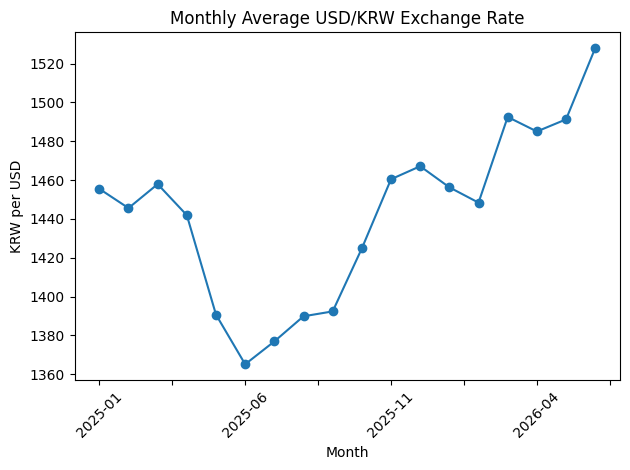

In [253]:
# 평균 환율 그래프

monthly_exchange.plot(
    x="month",
    y="avg_exchange_rate",
    kind="line",
    marker="o",
    legend=False
)

plt.title("Monthly Average USD/KRW Exchange Rate")
plt.xlabel("Month")
plt.ylabel("KRW per USD")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

※ 2025-06 최저치(1360원 가량) 이후 2025-10부터 급등

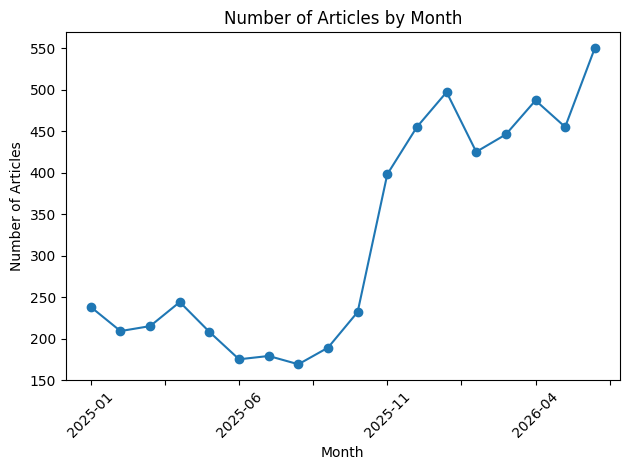

In [252]:
# (참고) 환율 기사 개수 추이

month_counts.plot(kind="line", marker="o")

plt.title("Number of Articles by Month")
plt.xlabel("Month")
plt.ylabel("Number of Articles")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

※ 상대적으로 환율이 하락하는 시기에는 관련 기사가 적었지만, 환율 급등하자 관련 기사도 급증함.

In [251]:
monthly_analysis = (
    monthly_summary
    .merge(
        monthly_exchange,
        on="month",
        how="left"
    )
)

monthly_analysis

,month,top_terms,avg_exchange_rate
0,2025-01,"환율, 고환율, 달러, 트럼프, 한국경제, 헤럴드경제, 2025, 2025년, 달러...",1455.500000
1,2025-02,"환율, 달러, 트럼프, 물가, 서울경제, 한국경제, 1월, 가격, 관세, 연합뉴스",1445.575000
2,2025-03,"환율, 달러, 가격, 인상, 경향신문, 달러 환율, 한국경제, 트럼프, 연합뉴스, 최상목",1457.915000
3,2025-04,"환율, 달러, 달러 환율, 관세, 연합뉴스, 최고, 강세, 트럼프, 1분기, 만에",1441.918182
4,2025-05,"환율, 달러, kb think, think, kb, 원화, 연합뉴스, 달러 환율, ...",1390.700000
5,2025-06,"환율, 달러, 이재명, 한국경제, 이란, 마켓인, 코스피, 원화, 정부, 달러 환율",1365.152632
6,2025-07,"환율, 달러, 달러 환율, daum, daum net, net, 상승, 2분기, 마...",1376.917391
7,2025-08,"달러, 환율, 달러 환율, 브런치, daum, daum net, net, ebc, ...",1389.860000
8,2025-09,"환율, 달러, 1400원, 환율 1400원, daum, daum net, net, ...",1392.377273
9,2025-10,"환율, 달러, 달러 환율, daum, daum net, net, 한국경제, 돌파, ...",1424.827778


※ 환율 급등 시기(2025-09 이후) '고환율' 자주 등장.
- 단 기사 제목만으로 분석하는 한계로 인하여 단어 자체는 크게 달라지지 않음
- 이슈 관련 단어는 환율 상승폭이 가장 높았던 시기(2026-03)에 강하게 등장(중동, 전쟁, 고유가)

#Conclusion

- More than 5,700 exchange-rate news articles were collected through Google News crawling.
- News volume increased noticeably during periods of higher exchange rates.
- Monthly TF-IDF analysis showed that headline vocabulary remained relatively stable across the observation period.
- Core terms such as exchange rate, dollar, and won appeared consistently, while event-related words (e.g., tariffs, Trump, Iran) emerged temporarily during specific months.
- These results suggest that exchange-rate headlines tended to maintain a consistent lexical structure despite substantial market fluctuations.

## Limitations

- The analysis used news headlines only, which provide limited context compared with full articles.
- TF-IDF identifies important words but cannot fully capture framing, sentiment, or causal narratives.
- News source names and common financial expressions also appeared frequently, limiting the interpretability of some keywords.

## Future Work
- Analyze article summaries or full texts instead of headlines only.
- Apply topic modeling (e.g., LDA or BERTopic) to identify broader discussion themes.
- Compare keyword changes with major economic or geopolitical events in greater detail.